<a href="https://colab.research.google.com/github/sultanerdin377/QLC-OCEANS/blob/main/exercise_4_coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Install the packages needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install netcdf4
import netCDF4
import urllib.request as urllib2

An ocean glider is a type of autonomous underwater vehicle (AUV) that doesn't use a propeller to move. Instead, it uses changes in buoyancy to travel long distances over months at a time.
How it moves:
Buoyancy Change: It has a motorized pump that moves oil into or out of an external bladder. When the bladder inflates, the glider becomes more buoyant and rises; when it deflates, the glider becomes denser and sinks.
Wings and Gliding: As the glider moves up and down, its fixed wings convert that vertical motion into horizontal forward thrust. This creates a constant "sawtooth" (zigzag) path through the water [2, 3].
Steering: To change direction, the glider either moves its internal battery pack to shift its center of gravity (causing it to roll or pitch) or uses a small tail rudder [3].

{'unixtime': '1370530681.4415', 'lat': ' 44.533653577385195', 'lon': ' -63.393453793673935', 'depth': ' 35.2', 'sci_water_sal': ' 31.852892253513247'}
{'unixtime': '1370530742.2388', 'lat': ' 44.53351946378085', 'lon': ' -63.39334395323845', 'depth': ' 26.06', 'sci_water_sal': ' 31.717310598606883'}
{'unixtime': '1370530802.37628', 'lat': ' 44.53338680568273', 'lon': ' -63.39323530487769', 'depth': ' 17.29', 'sci_water_sal': ' 31.462472169658824'}
{'unixtime': '1370530863.38712', 'lat': ' 44.5332522210279', 'lon': ' -63.39312507864697', 'depth': ' 8.83', 'sci_water_sal': ' 31.127901282228475'}
{'unixtime': '1370530924.34824', 'lat': ' 44.53311774605122', 'lon': ' -63.39301494224378', 'depth': ' 2.14', 'sci_water_sal': ' 31.03919875193208'}
{'unixtime': '1370530984.70169', 'lat': ' 44.532984611541806', 'lon': ' -63.392905903697226', 'depth': ' 0.08', 'sci_water_sal': ' 31.063125057254904'}
{'unixtime': '1370531045.39243', 'lat': ' 44.53306864305745', 'lon': ' -63.39281438058511', 'depth

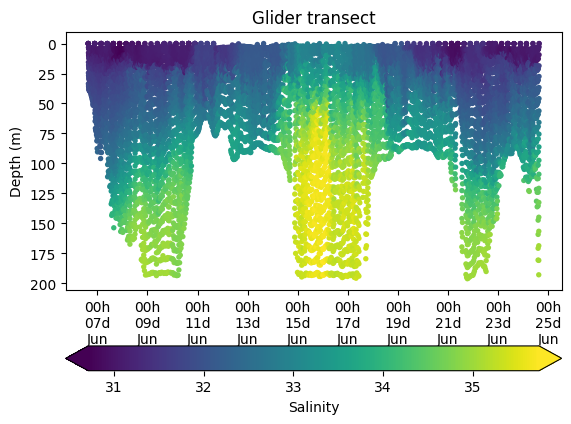

In [12]:
import csv
import matplotlib.pyplot as plt
from matplotlib import dates
import datetime
from io import StringIO
# Retreive data from the "glider" server
response = urllib2.urlopen('http://glider.ceotr.ca/data/live/otn200_sci_water_sal_live.csv')
data = response.read().decode('utf-8') #Decode the response to a string
data = StringIO(data)

# Read file
r = csv.DictReader(data)

# Print top 10 lines of dataframe
for i, row in enumerate(r):
    if i >= 10:
        break
    print(row)

# Initialize empty variables
date, lat, lon, depth, temp, = [], [], [], [], []
# Loop to parse data into our variables
for row in r:
    date.append(float(row['unixtime']))
    lat.append(float(row['lat']))
    lon.append(float(row['lon']))
    depth.append(float(row['depth']))
    temp.append(float(row['sci_water_sal']))
# Change unix-time into a date object (for easy plotting)
DATE = []
for row in date:
    DATE.append(datetime.datetime.fromtimestamp(row))
# Make plot
fig, ax1 = plt.subplots(1)
plt.scatter(DATE,depth,s=15,c=temp,marker='o',edgecolor='none')
#plt.ylim(-0.5,max(depth)+5))
ax1.set_ylim(ax1.get_ylim()[::-1])
cbar = plt.colorbar(orientation='horizontal', extend='both')
xfmt = dates.DateFormatter('%Hh\n%dd\n%b')
ax1.xaxis.set_major_formatter(xfmt)
cbar.set_label('Salinity')
plt.title('Glider transect')
plt.ylabel('Depth (m)')
plt.show()

In [ ]:
#install cmocean package
!pip install cmocean
# import cmocean package
import cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 11.8 MB/s eta 0:00:00
{'unixtime': '1370530254.25809', 'lat': ' 44.534030000000001', 'lon': ' -63.393878333300002', 'depth': ' 0.083147499999999999', 'sci_water_temp': ' 0.0'}
{'unixtime': '1370530355.41907', 'lat': ' 44.534115', 'lon': ' -63.393787304973607', 'depth': ' 0.79591684226945247', 'sci_water_temp': ' 0.0'}
{'unixtime': '1370530416.23221', 'lat': ' 44.534238606222544', 'lon': ' -63.39393293837054', 'depth': ' 4.3112462371670102', 'sci_water_temp': ' 9.0907'}
{'unixtime': '1370530620.40247', 'lat': ' 44.533788224224502', 'lon': ' -63.393564070834394', 'depth': ' 38.666863442968072', 'sci_water_temp': ' 0.0'}
{'unixtime': '1370530681.4415', 'lat': ' 44.533653577385195', 'lon': ' -63.393453793673935', 'depth': ' 34.513875660512575', 'sci_water_temp': ' 3.3461'}
{'unixtime': '1370530742.2388', 'lat': ' 44.533519463780848', 'lon': ' -63.39334395323845', 'depth': ' 25.014983891599616', 'sci_water_temp': ' 3.8327'}
{'unixti

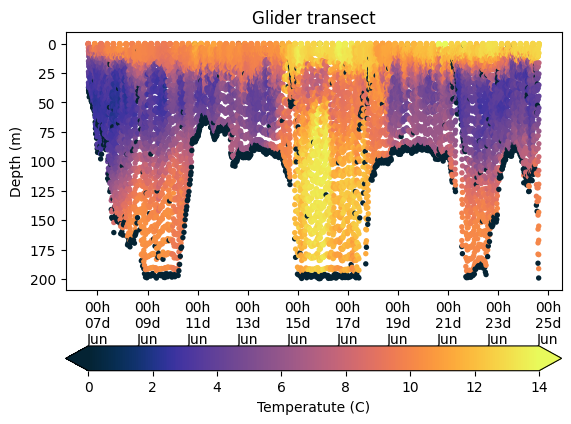

In [16]:
import csv
import matplotlib.pyplot as plt
from matplotlib import dates
import datetime
from io import StringIO

!pip install cmocean # Install cmocean if not already installed
import cmocean # Import cmocean here
# Retreive data from the "glider" server
response = urllib2.urlopen('http://glider.ceotr.ca/data/live/otn200_sci_water_temp_live.csv')
data = response.read().decode('utf-8') #Decode the response to a string
data = StringIO(data)

# Read file
r = csv.DictReader(data)

# Print top 10 lines of dataframe
for i, row in enumerate(r):
    if i >= 10:
        break
    print(row)

# Initialize empty variables
date, lat, lon, depth, temp, = [], [], [], [], []
# Loop to parse data into our variables
for row in r:
    date.append(float(row['unixtime']))
    lat.append(float(row['lat']))
    lon.append(float(row['lon']))
    depth.append(float(row['depth']))
    temp.append(float(row['sci_water_temp']))
# Change unix-time into a date object (for easy plotting)
DATE = []
for row in date:
    DATE.append(datetime.datetime.fromtimestamp(row))
# Make plot
fig, ax1 = plt.subplots(1)
plt.scatter(DATE,depth,s=15,c=temp,marker='o',edgecolor='none',cmap=cmocean.cm.thermal)
#plt.ylim(-0.5,max(depth)+5))
ax1.set_ylim(ax1.get_ylim()[::-1])
cbar = plt.colorbar(orientation='horizontal', extend='both')
xfmt = dates.DateFormatter('%Hh\n%dd\n%b')
ax1.xaxis.set_major_formatter(xfmt)
cbar.set_label('Temperatute (C)')
plt.title('Glider transect')
plt.ylabel('Depth (m)')
plt.show()